# NYC Taxi Trip Duration - Model Training & Evaluation

Ce notebook entraîne et évalue le modèle Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, '..')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Chargement des données prétraitées

In [2]:
from src.data.preprocessing import DataPreprocessor
from src.model.training import ModelTrainer

# Initialiser
trainer = ModelTrainer(config_path='../configs/config.yaml')

# Corriger les chemins (relatifs au notebook)
trainer.processed_path = Path('..') / trainer.processed_path
trainer.model_dir = Path('..') / trainer.model_dir

# Charger les données
train_df = trainer.load_processed_data('train_processed.csv')

print(f"\nDataset shape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")

Loading data from ../data/processed/train_processed.csv

Dataset shape: (1456886, 21)

Columns: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week', 'distance', 'manhattan_distance', 'direction_ns', 'direction_ew']


## 2. Préparation des features

In [3]:
# Préparer les features
X, y = trainer.prepare_features(train_df, is_train=True)

print(f"\nFeatures prepared successfully!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature names:")
print(X.columns.tolist())

Features shape: (1456886, 16)
Target shape: (1456886,)
Feature columns: ['day', 'day_of_week', 'direction_ew', 'direction_ns', 'distance', 'dropoff_latitude', 'dropoff_longitude', 'hour', 'manhattan_distance', 'minute', 'month', 'passenger_count', 'pickup_latitude', 'pickup_longitude', 'vendor_id', 'year']

Features prepared successfully!
X shape: (1456886, 16)
y shape: (1456886,)

Feature names:
['day', 'day_of_week', 'direction_ew', 'direction_ns', 'distance', 'dropoff_latitude', 'dropoff_longitude', 'hour', 'manhattan_distance', 'minute', 'month', 'passenger_count', 'pickup_latitude', 'pickup_longitude', 'vendor_id', 'year']


## 3. Entraînement du modèle

In [4]:
print("="*60)
print("ENTRAÎNEMENT DU MODÈLE")
print("="*60)

# Entraîner
metrics = trainer.train(X, y)

print("\n" + "="*60)
print("RÉSULTATS")
print("="*60)
for metric_name, metric_value in metrics.items():
    print(f"{metric_name.upper():6s}: {metric_value:.4f}")

ENTRAÎNEMENT DU MODÈLE

Training set size: (1165508, 16)
Test set size: (291378, 16)

Training Random Forest model...
Training completed!

Model Performance:
  MSE:  10956035.4134
  RMSE: 3309.9902
  MAE:  408.0302
  R²:   -0.0976

RÉSULTATS
MSE   : 10956035.4134
RMSE  : 3309.9902
MAE   : 408.0302
R2    : -0.0976


## 4. Importance des features


Top 15 Features by Importance:
           feature  importance
   pickup_latitude    0.210787
      direction_ew    0.195494
          distance    0.135536
manhattan_distance    0.084105
      direction_ns    0.058583
  dropoff_latitude    0.046921
              hour    0.045337
             month    0.042493
  pickup_longitude    0.040603
 dropoff_longitude    0.038492
               day    0.037559
       day_of_week    0.031021
            minute    0.023276
   passenger_count    0.006237
         vendor_id    0.003556


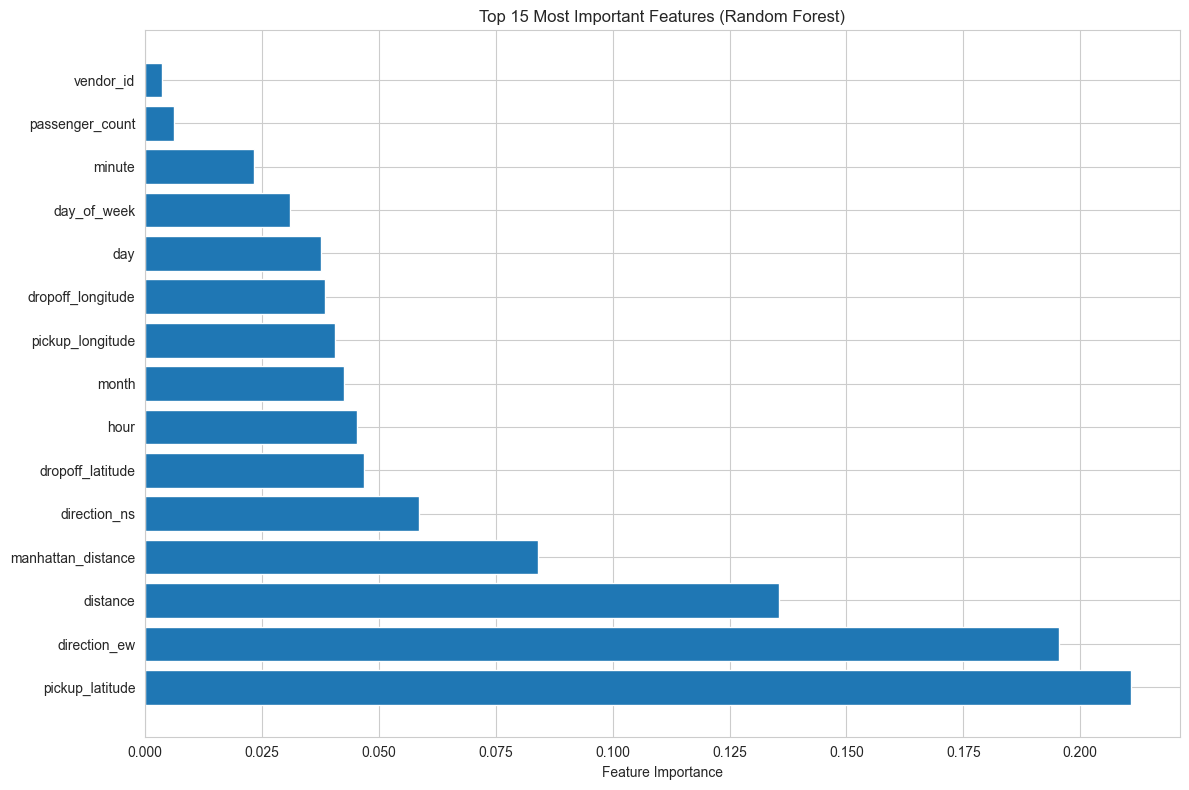

In [5]:
# Obtenir l'importance des features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': trainer.model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Features by Importance:")
print(feature_importance.head(15).to_string(index=False))

# Visualisation
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

## 5. Sauvegarde du modèle

In [6]:
# Sauvegarder
trainer.save_model()
print("\n✓ Modèle sauvegardé avec succès!")

Model saved to ../models/taxi_model.pkl
Model metadata saved to ../models/model_metadata.json

✓ Modèle sauvegardé avec succès!


## 6. Analyse des erreurs de prédiction


Analyse des Erreurs:
Mean Absolute Error (MAE): 408.03 seconds (6.80 minutes)
Median Absolute Error: 168.96 seconds (2.82 minutes)
Max Error: 332071.98 seconds (5534.53 minutes)
Mean Percentage Error: 72.55%


/var/folders/qr/9dzdswh156z2j48g5gmyg_600000gn/T/ipykernel_62691/1585236207.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([errors / 60], labels=['Errors'])


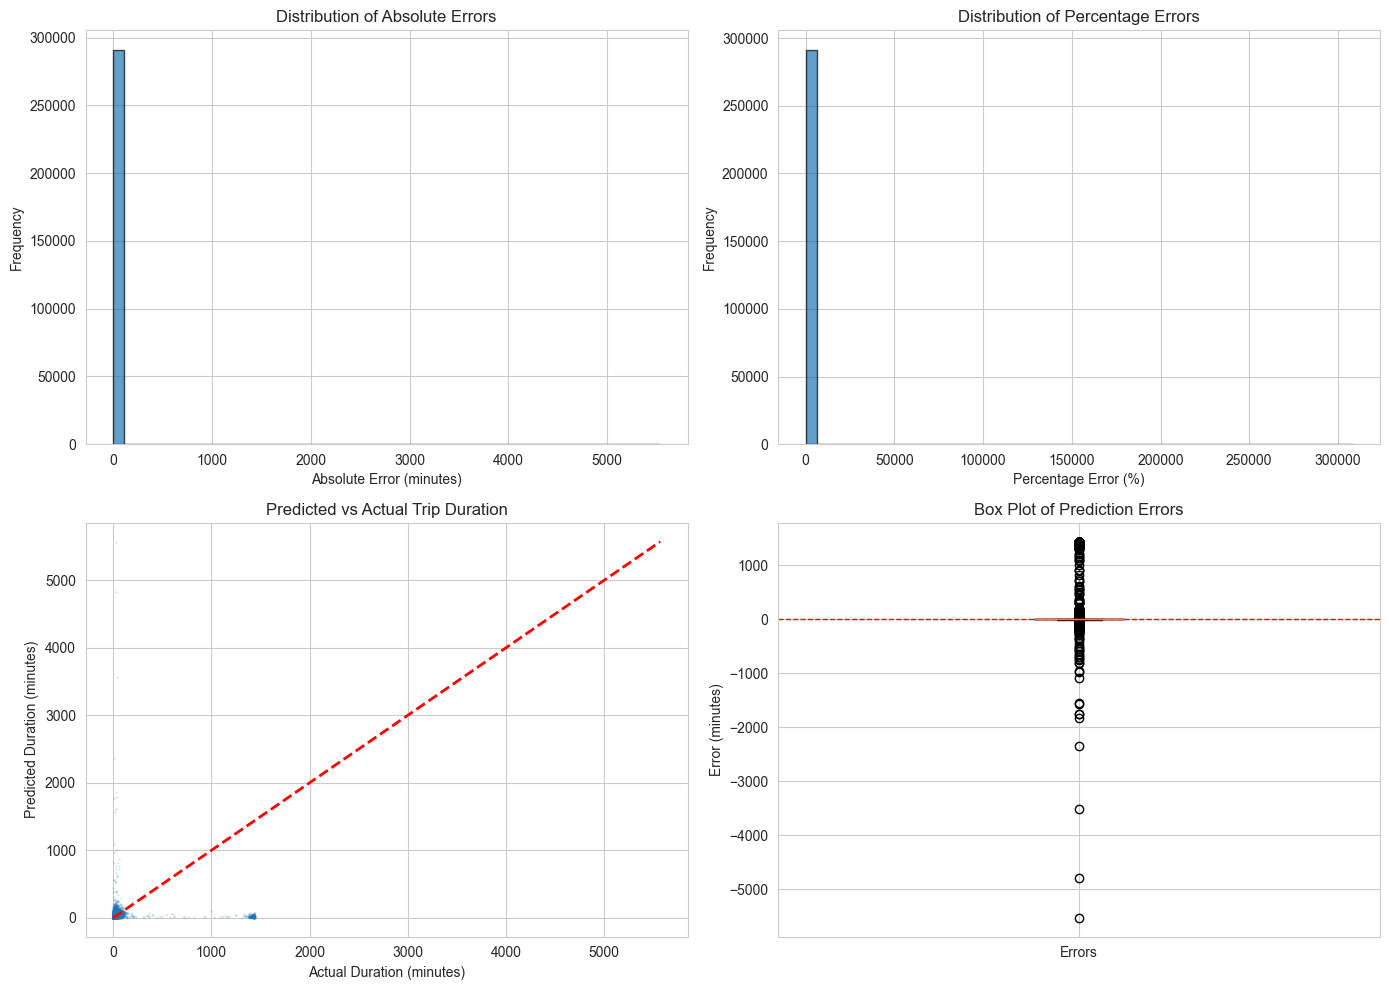

In [7]:
from sklearn.model_selection import train_test_split

# Faire des prédictions sur le test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = trainer.model.predict(X_test)

# Calculer les erreurs
errors = y_test.values - y_pred
absolute_errors = np.abs(errors)
percentage_errors = np.abs(errors) / y_test.values * 100

print("\nAnalyse des Erreurs:")
print(f"Mean Absolute Error (MAE): {absolute_errors.mean():.2f} seconds ({absolute_errors.mean()/60:.2f} minutes)")
print(f"Median Absolute Error: {np.median(absolute_errors):.2f} seconds ({np.median(absolute_errors)/60:.2f} minutes)")
print(f"Max Error: {absolute_errors.max():.2f} seconds ({absolute_errors.max()/60:.2f} minutes)")
print(f"Mean Percentage Error: {percentage_errors.mean():.2f}%")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Erreurs absolues
axes[0, 0].hist(absolute_errors / 60, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Absolute Error (minutes)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Absolute Errors')

# Erreurs en pourcentage
axes[0, 1].hist(percentage_errors, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Percentage Error (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Percentage Errors')

# Prédictions vs Réalité
axes[1, 0].scatter(y_test.values / 60, y_pred / 60, alpha=0.1, s=1)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1, 0].plot([lims[0]/60, lims[1]/60], [lims[0]/60, lims[1]/60], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Duration (minutes)')
axes[1, 0].set_ylabel('Predicted Duration (minutes)')
axes[1, 0].set_title('Predicted vs Actual Trip Duration')

# Box plot des erreurs
axes[1, 1].boxplot([errors / 60], labels=['Errors'])
axes[1, 1].set_ylabel('Error (minutes)')
axes[1, 1].set_title('Box Plot of Prediction Errors')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=1)

plt.tight_layout()
plt.show()